# Gaussian Processes Summer School

## Part 1: GP Regression and Random Fourier Features

<a href="https://www.uc3m.es/"><img src="https://www.uc3m.es/ss/Satellite?blobcol=urldata&amp;blobkey=id&amp;blobtable=MungoBlobs&amp;blobwhere=1371614316787&amp;ssbinary=true" alt="Universidad Carlos III de Madrid" width="360"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)  
**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

A compact introduction to GP regression, marginal-likelihood training in GPyTorch, and random Fourier feature approximations of the RBF kernel.

## Learning goals

1. Review the GP prior, Gaussian likelihood, posterior, and marginal likelihood.
2. Learn RBF hyperparameters by evidence maximization in GPyTorch.
3. Predict sparsely observed held-out signals using population-level hyperparameters.
4. Derive random Fourier features from Bochner's theorem.
5. Measure RFF approximation error versus the number of sampled frequencies.

In [9]:
import gpytorch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

seed = 7
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(seed)
torch.manual_seed(seed)
print("PyTorch:", torch.__version__, "| GPyTorch:", gpytorch.__version__)

PyTorch: 2.6.0+cu124 | GPyTorch: 1.15.2


## 1. Quick recap: Gaussian processes for regression

Assuming a zero prior mean, a Gaussian process is a distribution over functions:

$$f(x)\sim\mathcal{GP}\bigl(0,k_\theta(x,x')\bigr).$$

At training inputs $X=(x_1,\ldots,x_N)$, the function values satisfy

$$\mathbf f=f(X)\sim\mathcal N(\mathbf 0,K_\theta),\qquad [K_\theta]_{ij}=k_\theta(x_i,x_j).$$

Using the RBF kernel,

$$k_{\mathrm{RBF}}(x,x')=\sigma_f^2\exp\left[-\frac{(x-x')^2}{2\ell^2}\right],$$

where $\ell$ (lengthscale) controls how rapidly the function changes and $\sigma_f^2$ (output variance or output scale) controls its marginal variance. With Gaussian observation noise,

$$y_i=f(x_i)+\varepsilon_i,\qquad \varepsilon_i\sim\mathcal N(0,\sigma_n^2),$$

the observations follow

$$\mathbf y\sim\mathcal N\left(\mathbf 0,K_\theta+\sigma_n^2I\right).$$

For test inputs $X_*$, define

$$K_y=K(X,X)+\sigma_n^2I,\qquad K_*=K(X,X_*),\qquad K_{**}=K(X_*,X_*).$$

The posterior distribution of the latent test values is Gaussian:

$$\mathbf f_*\mid\mathbf y\sim\mathcal N(\boldsymbol\mu_*,\Sigma_*),$$

with
$$\boldsymbol\mu_*=K_*^\top K_y^{-1}\mathbf y,$$

$$\Sigma_*=K_{**}-K_*^\top K_y^{-1}K_*.$$

Thus, the posterior follows the observations near the training data and returns toward zero, with increasing uncertainty, farther away. The variance $\Sigma_*$ reveals that the uncertainty in predictions depends solely on the input values $X$ and $X_∗$, not on the observed outputs $\mathbf y$. This characteristic is a distinctive property of Gaussian distributions.

### Synthetic database of GP signals

We generate independent signals from one shared RBF GP:

$$f_i\sim\mathcal{GP}(0,k_{\mathrm{RBF}}),\qquad \mathbf y_i=\mathbf f_i+\boldsymbol\varepsilon_i.$$

On the finite grid, exact GP samples use a Cholesky factor:

$$K+\delta I=LL^\top,\qquad \boldsymbol\xi_i\sim\mathcal N(0,I),\qquad \mathbf f_i=L\boldsymbol\xi_i.$$

The tiny $\delta$ stabilizes the factorization and is distinct from observation noise.

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background-color:#fde8e8; border:2px solid #c62828; border-radius:8px; padding:14px 18px; margin:14px 0; color:#7f0000;">
<strong>Woodbury matrix identity</strong>

For an $N\times N$ covariance matrix, computing the Cholesky factor costs $O(N^3)$ operations. To obtain each successive column of $L$, the algorithm performs work proportional to the square of the remaining matrix size; summing this work over all $N$ columns gives roughly $N^3/3$ operations. Storing $K$ and $L$ requires $O(N^2)$ memory. Once $L$ has been computed, drawing each GP sample through $L\boldsymbol\xi_i$ costs only $O(N^2)$, so the same factor can be reused for all signals sampled on the same grid with the same kernel.



In [14]:
rng = np.random.default_rng(seed)
n_signals, n_points = 80, 120
x = np.linspace(0.0, 1.0, n_points)

true_mean = 0.0
true_lengthscale = 0.05
true_outputscale = 1.20
true_noise_std = 0.02
true_noise_variance = true_noise_std**2

tau = x[:, None] - x[None, :] #shape (n_points, n_points) contains the pairwise differences between all points in x
K_true = true_outputscale * np.exp(-tau**2 / (2 * true_lengthscale**2))
L_true = np.linalg.cholesky(K_true + 1e-8 * np.eye(n_points)) #Order of Cholesky decomposition is O(n^3) and can be slow for large n_points. The 1e-8 term is added for numerical stability.
latent_signals = rng.standard_normal((n_signals, n_points)) @ L_true.T
signals = true_mean + latent_signals + true_noise_std * rng.standard_normal(latent_signals.shape)

permutation = rng.permutation(n_signals)
n_train = int(0.8 * n_signals)
train_signals = signals[permutation[:n_train]]
test_signals = signals[permutation[n_train:]]
print("train:", train_signals.shape, "| test:", test_signals.shape)

train: (64, 120) | test: (16, 120)


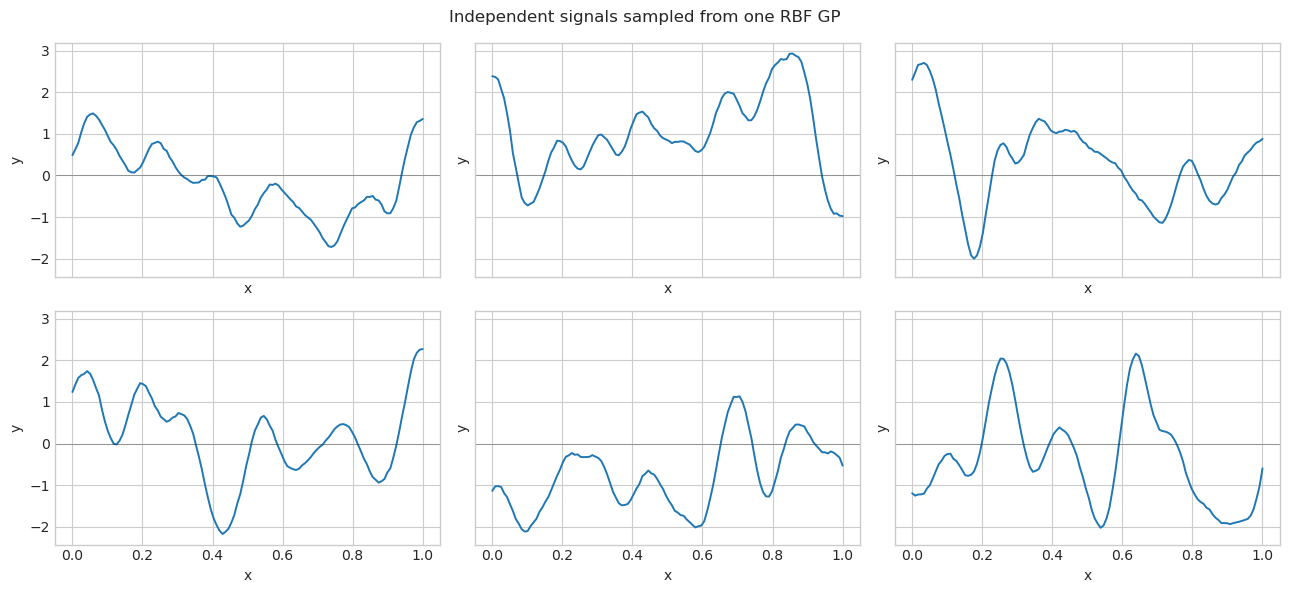

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
for signal, ax in zip(train_signals[:6], axes.flat):
    ax.plot(x, signal, linewidth=1.4)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)
    ax.set(xlabel="x", ylabel="y")
fig.suptitle("Independent signals sampled from one RBF GP")
fig.tight_layout()
plt.show()

## 2. Hyperparameter learning by marginal likelihood

For one signal, the log evidence is

$$\log p(\mathbf y\mid X,\theta)=-\tfrac12\mathbf y^\top K_y^{-1}\mathbf y-\tfrac12\log|K_y|-\tfrac N2\log(2\pi).$$

The three terms have distinct roles:

- **Data-fit term:** $-\tfrac12\mathbf y^\top K_y^{-1}\mathbf y$ is the negative squared Mahalanobis distance between the observations and the zero prior mean. It is large (less negative) when $K_y$ assigns high probability to the observed pattern. For example, a suitable lengthscale makes variations that occur in $\mathbf y$ plausible.
- **Complexity term:** $-\tfrac12\log|K_y|$ measures the volume of outputs to which the model assigns substantial probability. A very large output scale or noise variance can reduce the quadratic penalty by making many possible datasets plausible, but it also enlarges $|K_y|$ and therefore makes this term more negative. See the [geometric note on covariance and volume](#covariance-volume) near the end of the notebook.
- **Constant:** $-\tfrac N2\log(2\pi)$ normalizes the Gaussian density and does not depend on the hyperparameters.

The first two terms therefore compete. The model cannot improve its score simply by increasing its variance: it must assign probability specifically to the observed data without spreading that probability over too many other possible datasets. This built-in preference for the simplest covariance structure that still explains the data is called the **Occam penalty**.

Our training signals are conditionally independent with shared hyperparameters, so

$$\log p(Y\mid X,\theta)=\sum_{i=1}^{n_{\mathrm{train}}}\log p(\mathbf y_i\mid X,\theta).$$

We maximize the average log evidence. Averaging leaves the optimum unchanged while keeping gradient scale independent of database size.

### Basic GPyTorch pattern

An exact model defines a mean module, a covariance module, and a Gaussian likelihood. GPyTorch internally constrains lengthscale, output scale, and noise to remain positive.

In [32]:
class ExactRBFModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(#ScaleKernel is used to scale the output of the RBF kernel by a learnable outputscale parameter
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x_input):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x_input), self.covar_module(x_input)
        )


train_x = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
train_y = torch.tensor(train_signals, dtype=torch.float32)
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactRBFModel(train_x, train_y, likelihood)
model.mean_module.initialize(constant=0.0)
model.mean_module.constant.requires_grad_(False) # We fix it to the true mean value, so that we can focus on learning the kernel hyperparameters and noise variance
model.covar_module.base_kernel.initialize(lengthscale=0.30) # True lenghscale is 0.05, but we initialize with a larger value to see if the model can learn it from the data
model.covar_module.initialize(outputscale=0.80) # True outputscale is 1.20, but we initialize with a smaller value to see if the model can learn it from the data
likelihood.initialize(noise=0.02)

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [33]:
model.train(); likelihood.train() #.train() sets the model and likelihood into training mode, which is necessary for certain layers like dropout or batch normalization to behave correctly during training.
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
losses = []

for step in range(1, 121):
    optimizer.zero_grad()
    loss = -mll(model(train_x), train_y).mean()
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))
    if step == 1 or step % 30 == 0:
        print(
            f"step {step:3d} | NLL={losses[-1]:.4f} | "
            f"ell={model.covar_module.base_kernel.lengthscale.item():.4f} | "
            f"scale={model.covar_module.outputscale.item():.4f} | "
            f"noise={likelihood.noise.item():.5f}"
        )

step   1 | NLL=11.4251 | ell=0.2873 | scale=0.8278 | noise=0.02101
step  30 | NLL=0.3121 | ell=0.0898 | scale=1.6375 | noise=0.05516
step  60 | NLL=-0.0456 | ell=0.0585 | scale=1.9169 | noise=0.05650
step  90 | NLL=-0.1188 | ell=0.0563 | scale=1.9043 | noise=0.04684
step 120 | NLL=-0.2111 | ell=0.0564 | scale=1.8534 | noise=0.03699


,true,learned
parameter,,
mean,0.00000,0.00000
lengthscale,0.05000,0.05645
output scale,1.20000,1.85339
noise variance,0.00040,0.03699


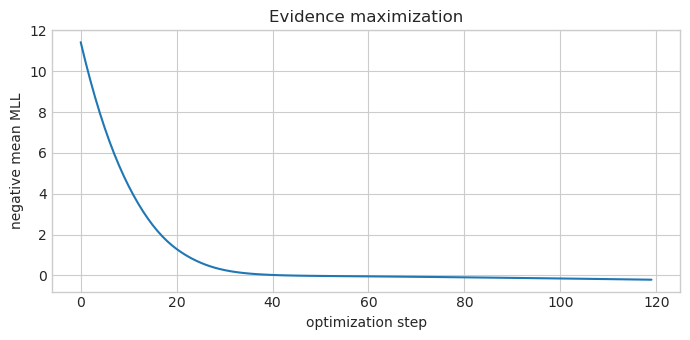

In [34]:
learned_mean = model.mean_module.constant.item()
learned_lengthscale = model.covar_module.base_kernel.lengthscale.item()
learned_outputscale = model.covar_module.outputscale.item()
learned_noise = likelihood.noise.item()

table = pd.DataFrame({
    "parameter": ["mean", "lengthscale", "output scale", "noise variance"],
    "true": [true_mean, true_lengthscale, true_outputscale, true_noise_variance],
    "learned": [learned_mean, learned_lengthscale, learned_outputscale, learned_noise],
}).set_index("parameter")
display(table.style.format(precision=5).set_caption("True versus learned GP parameters"))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses)
ax.set(title="Evidence maximization", xlabel="optimization step", ylabel="negative mean MLL")
fig.tight_layout(); plt.show()

### Sparse regression on held-out signals

The database learns population hyperparameters. For each new signal, we keep those values fixed and condition only on a small irregular subset of its observations.

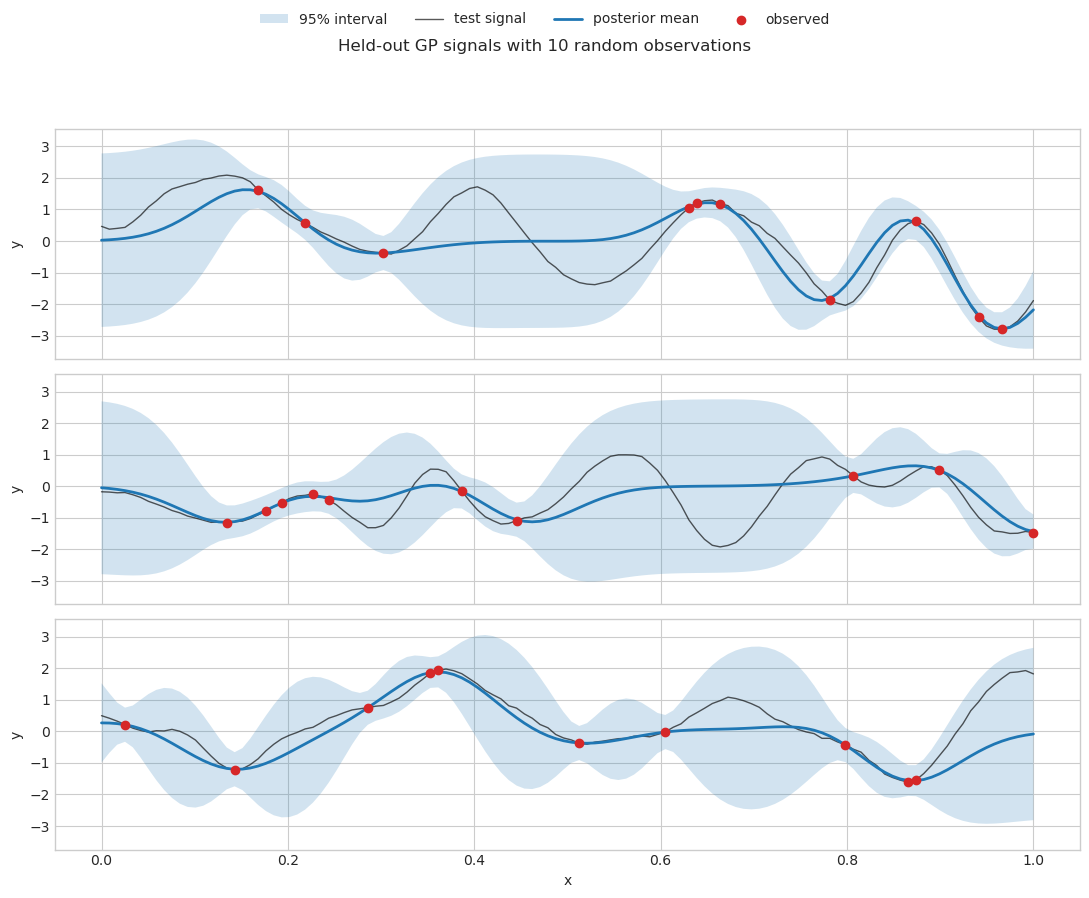

In [36]:
def predict_signal(observed_x, observed_y, prediction_x):
    x_obs = torch.tensor(observed_x, dtype=torch.float32).unsqueeze(-1)
    y_obs = torch.tensor(observed_y, dtype=torch.float32)
    x_pred = torch.tensor(prediction_x, dtype=torch.float32).unsqueeze(-1)
    # We create a new likelihood and model for the prediction, using the learned hyperparameters from the training phase. This allows us to make predictions on new data points while leveraging the information learned from the training signals.
    local_likelihood = gpytorch.likelihoods.GaussianLikelihood()
    local_model = ExactRBFModel(x_obs, y_obs, local_likelihood)
    local_model.mean_module.initialize(constant=learned_mean)
    local_model.covar_module.base_kernel.initialize(lengthscale=learned_lengthscale)
    local_model.covar_module.initialize(outputscale=learned_outputscale)
    local_likelihood.initialize(noise=learned_noise)
    local_model.eval(); local_likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictive = local_likelihood(local_model(x_pred))
        lower, upper = predictive.confidence_region()
    return predictive.mean.numpy(), lower.numpy(), upper.numpy()


plot_rng = np.random.default_rng(seed + 1)
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, sharey=True)
for signal, ax in zip(test_signals[:3], axes):
    # We randomly select 10 indices from the test signal to simulate observed data points. These indices are sorted to maintain the order of the x values.
    indices = np.sort(plot_rng.choice(n_points, size=10, replace=False))
    mean, lower, upper = predict_signal(x[indices], signal[indices], x)
    ax.fill_between(x, lower, upper, alpha=0.2, label="95% interval")
    ax.plot(x, signal, color="black", alpha=0.65, linewidth=1, label="test signal")
    ax.plot(x, mean, linewidth=2, label="posterior mean")
    ax.scatter(x[indices], signal[indices], color="C3", zorder=5, label="observed")
    ax.set_ylabel("y")
axes[-1].set_xlabel("x")
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc="upper center", ncol=4)
fig.suptitle("Held-out GP signals with 10 random observations", y=0.96)
fig.tight_layout(rect=(0, 0, 1, 0.91)); plt.show()

## 3. Random Fourier features

So far, the kernel has allowed us to compare any pair of inputs directly. This is elegant, but it requires building and working with an $N\times N$ covariance matrix. Random Fourier features (RFFs) offer a different viewpoint: instead of evaluating the kernel for every pair, we first map each input $x$ to a finite feature vector $z(x)$ and then use an ordinary inner product,

$$k(x,x')\approx z(x)^\top z(x').$$

The key intuition is that a stationary kernel can be assembled by combining sinusoidal patterns with different frequencies. For the RBF kernel, smooth low-frequency patterns are sampled more often than rapidly oscillating ones. With enough sampled frequencies, their average reproduces the original kernel increasingly well.

This section develops that idea in three steps: connect stationary kernels to frequencies, replace an expectation over frequencies by a finite Monte Carlo average, and collect the resulting sines and cosines into $z(x)$. The theorem below provides the mathematical foundation; the practical construction that follows is simply a randomized feature map.

### Quick review: when is a function a valid kernel?

A real-valued function $k(x,x')$ is a valid covariance kernel when it satisfies two conditions:

1. **Symmetry:** $k(x,x')=k(x',x)$. Covariance should not depend on the order of the two inputs.
2. **Positive semidefiniteness:** for every finite collection of inputs $x_1,\ldots,x_N$ and every vector of real coefficients $\mathbf c=(c_1,\ldots,c_N)^\top$,

   $$\mathbf c^\top K\mathbf c=\sum_{i=1}^N\sum_{j=1}^N c_i c_j k(x_i,x_j)\geq0,$$

   where $K_{ij}=k(x_i,x_j)$ is the Gram matrix. Equivalently, every Gram matrix produced by the kernel must have non-negative eigenvalues.

This condition is necessary because $\mathbf c^\top K\mathbf c$ is the variance of the linear combination $\sum_i c_i f(x_i)$, and a variance cannot be negative. The word *semidefinite* allows this variance to be zero for some nonzero $\mathbf c$; a strictly positive-definite kernel requires it to be positive for every nonzero $\mathbf c$ (under the appropriate conditions on the inputs).

### Bochner's theorem  


Bochner's theorem states that a continuous stationary function is a valid positive-semidefinite kernel if and only if it is the Fourier transform of a finite non-negative measure. For a normalized kernel with $k(0)=1$, write that measure as a probability density $p(\omega)$ over the spectral space $\omega\in\mathbb R^d$, where $d$ is the dimension of $x$. If $\tau = x_i - x_j$:

$$k(\tau)=\int_{\mathbb R^d}e^{i\omega^\top\tau}p(\omega)d\omega=\mathbb E_{\omega\sim p}\left[e^{i\omega^\top\tau}\right].$$

The requirement $p(\omega)\geq0$ guarantees positive semidefiniteness. Now expand the complex exponential using **Euler's formula**:

$$e^{i\omega^\top\tau}=\cos(\omega^\top\tau)+i\sin(\omega^\top\tau).$$

Therefore,

$$k(\tau)=\int\cos(\omega^\top\tau)p(\omega)d\omega+i\int\sin(\omega^\top\tau)p(\omega)d\omega.$$

A covariance kernel for a real-valued stationary process must itself be real and even: $k(\tau)=k(-\tau)$. This corresponds to a symmetric spectral density,

$$p(\omega)=p(-\omega).$$

Because sine is odd and $p$ is even, its integral cancels pairwise:

$$\int\sin(\omega^\top\tau)p(\omega)d\omega=0.$$

Only the real cosine part remains:

$$k(\tau)=\int\cos(\omega^\top\tau)p(\omega)d\omega=\mathbb E_{\omega\sim p}[\cos(\omega^\top\tau)].$$

Here “positive” means that every covariance matrix built from $k$ is positive semidefinite; it does **not** mean that $k(\tau)$ must be positive at every lag. Valid oscillatory kernels can have negative covariance values.

For the normalized RBF kernel,

$$k_{\mathrm{RBF}}(\tau)=\exp\!\left(-\frac{\tau^2}{2\ell^2}\right),\qquad \omega\sim\mathcal N(\mathbf 0,\ell^{-2}\mathbf I).$$

### Monte Carlo approximation of a kernel

Draw $D$ samples $\omega_1, \omega_2, ... \omega_D$ from the spectral distribution $\omega\sim\mathcal N(\mathbf 0,\ell^{-2}\mathbf I)$. Then

$$k(x-x') \approx \frac1D\sum_{d=1}^D\cos(\omega_d^\top(x-x')).$$

If we use that $\cos(a-b) = \cos(a)\cos(b)-\sin(a)\sin(b)$, then

$$k(x-x') \approx \frac1D\sum_{d=1}^D \cos(\omega_d^\top x)\cos(\omega_d^\top x')-\sin(\omega_d^\top x)\sin(\omega_d^\top x')$$

$$z(x)=\sqrt{\frac1D}[\cos(\omega_1x),\sin(\omega_1x),\ldots,\cos(\omega_Dx),\sin(\omega_Dx)]^\top.$$

Then

$$k(x-x')\approx z(x)^\top z(x')=\frac1D\sum_{d=1}^D\cos(\omega_d(x-x')).$$

Thus $D$ sampled frequencies produce $L=2D$ real features. The estimator is unbiased and its Monte Carlo error decreases approximately as $O(D^{-1/2})$.

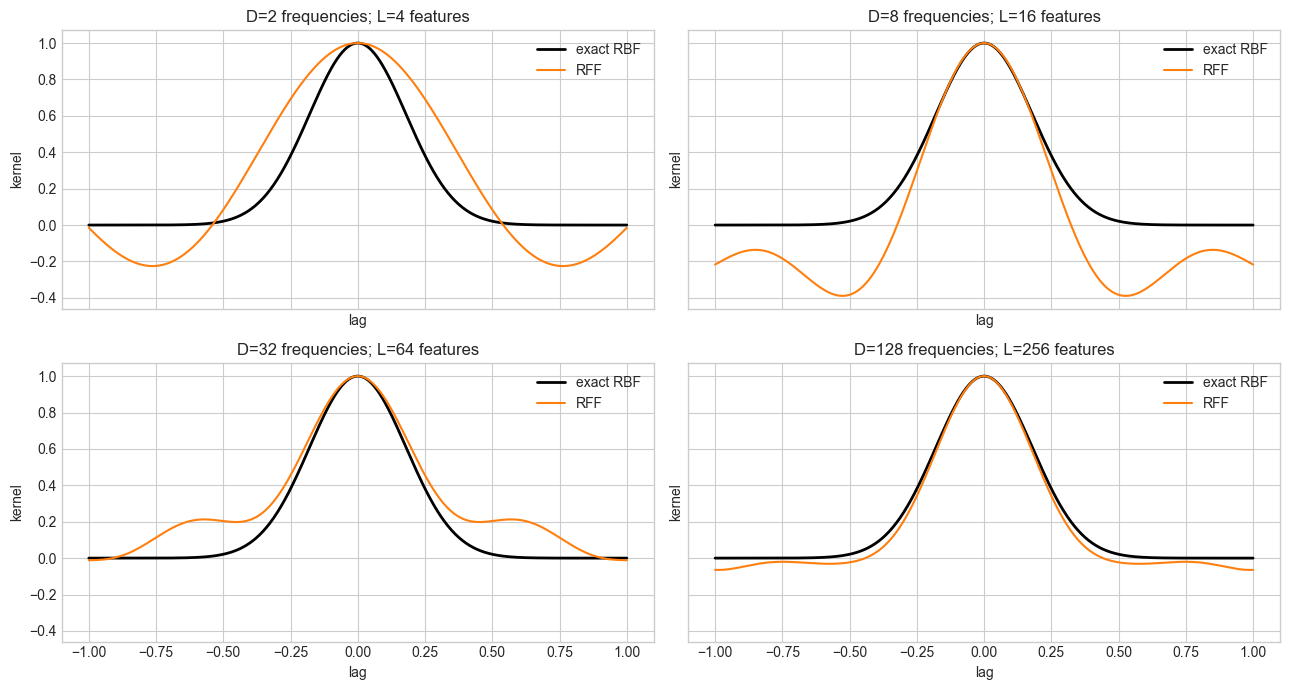

In [29]:
def rff_features(x_values, lengthscale, D, rng):
    omega = rng.normal(0.0, 1.0 / lengthscale, size=D)
    projection = np.outer(x_values, omega)
    return np.sqrt(1.0 / D) * np.concatenate(
        [np.cos(projection), np.sin(projection)], axis=1
    )


lag_grid = np.linspace(-1.0, 1.0, 600)
exact_lag_kernel = np.exp(-lag_grid**2 / (2 * true_lengthscale**2))
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for D, ax in zip([2, 8, 32, 128], axes.flat):
    omega = np.random.default_rng(seed + D).normal(0, 1 / true_lengthscale, D)
    approximation = np.cos(np.outer(lag_grid, omega)).mean(axis=1)
    ax.plot(lag_grid, exact_lag_kernel, color="black", linewidth=2, label="exact RBF")
    ax.plot(lag_grid, approximation, color="C1", label="RFF")
    ax.set(title=f"D={D} frequencies; L={2 * D} features", xlabel="lag", ylabel="kernel")
    ax.legend()
fig.tight_layout(); plt.show()

### Approximation error versus number of samples

For each $D$, repeat the frequency draw and measure relative matrix error:

$$\operatorname{error}(D)=\frac{\|K_{\mathrm{RFF}}-K_{\mathrm{RBF}}\|_F}{\|K_{\mathrm{RBF}}\|_F}.$$

The band shows one standard deviation across random RFF draws.

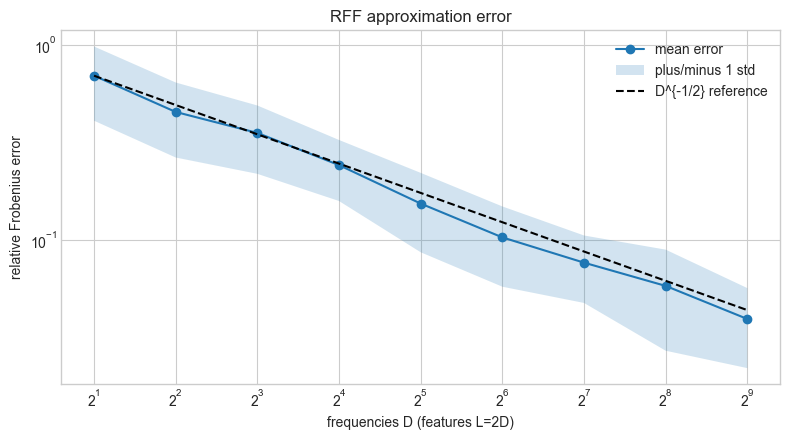

,frequencies D,features L,mean relative error,std
0,2,4,0.69541,0.28700
1,4,8,0.45298,0.18871
2,8,16,0.35339,0.13552
3,16,32,0.24155,0.08360
4,32,64,0.15328,0.06711
5,64,128,0.10275,0.04542
6,128,256,0.07620,0.02889
7,256,512,0.05789,0.03099
8,512,1024,0.03915,0.01725


In [30]:
x_error = np.linspace(0, 1, 60)
tau_error = x_error[:, None] - x_error[None, :]
K_exact = np.exp(-tau_error**2 / (2 * true_lengthscale**2))
counts = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512])
errors = np.empty((len(counts), 30))

for row, D in enumerate(counts):
    for repetition in range(errors.shape[1]):
        features = rff_features(
            x_error, true_lengthscale, int(D),
            np.random.default_rng(10_000 + 100 * row + repetition),
        )
        K_rff = features @ features.T
        errors[row, repetition] = (
            np.linalg.norm(K_rff - K_exact, "fro") / np.linalg.norm(K_exact, "fro")
        )

mean_error, std_error = errors.mean(1), errors.std(1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(counts, mean_error, marker="o", label="mean error")
ax.fill_between(counts, mean_error - std_error, mean_error + std_error, alpha=0.2, label="plus/minus 1 std")
ax.plot(counts, mean_error[0] * np.sqrt(counts[0] / counts), "k--", label="D^{-1/2} reference")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set(xlabel="frequencies D (features L=2D)", ylabel="relative Frobenius error", title="RFF approximation error")
ax.legend(); fig.tight_layout(); plt.show()

display(pd.DataFrame({
    "frequencies D": counts,
    "features L": 2 * counts,
    "mean relative error": mean_error,
    "std": std_error,
}).style.format(precision=5).set_caption("Monte Carlo RFF kernel error"))

### Why random features can make GP inference scalable

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background-color:#fde8e8; border:2px solid #c62828; border-radius:8px; padding:14px 18px; margin:14px 0; color:#7f0000;">
<strong>Woodbury matrix identity</strong>

Let

$$A\in\mathbb R^{N\times N},\qquad U\in\mathbb R^{N\times L},\qquad C\in\mathbb R^{L\times L},\qquad V\in\mathbb R^{L\times N},$$

where $A$ and $C$ are invertible and typically $L\ll N$. Then $A+UCV\in\mathbb R^{N\times N}$ and

$$(A+UCV)^{-1}=A^{-1}-A^{-1}U\left(C^{-1}+VA^{-1}U\right)^{-1}VA^{-1}.$$

The inner matrix $C^{-1}+VA^{-1}U$ has dimension $L\times L$.

<strong>RFF specialization</strong>

For $A=\sigma_n^2I_N$, $U=\Phi$, $C=\sigma_f^2I_L$, and $V=\Phi^\top$, both $A^{-1}=\sigma_n^{-2}I_N$ and $C^{-1}=\sigma_f^{-2}I_L$ are just elementwise scalings. Their application costs $O(N)$ and $O(L)$, respectively, rather than cubic time. The remaining work is to form $\Phi^\top\Phi$ in $O(NL^2)$ and factorize one $L\times L$ matrix in $O(L^3)$.
</div>

Let $\Phi\in\mathbb R^{N\times L}$ be the RFF design matrix whose $i$th row is $z(x_i)^\top$. With $L=2D$ real features, the covariance approximation is

$$K\approx\sigma_f^2\Phi\Phi^\top.$$

After adding observation noise, the matrix required for GP regression is

$$K_y=\sigma_n^2I_N+\sigma_f^2\Phi\Phi^\top.$$

A direct exact-GP implementation factorizes the $N\times N$ matrix $K_y$, requiring $O(N^3)$ time and $O(N^2)$ memory. Because the RFF covariance has rank at most $L$, the **Woodbury matrix identity** moves the expensive solve into feature space:

$$K_y^{-1}=\sigma_n^{-2}I_N-\sigma_n^{-4}\Phi\left(\sigma_f^{-2}I_L+\sigma_n^{-2}\Phi^\top\Phi\right)^{-1}\Phi^\top.$$

Instead of factorizing an $N\times N$ matrix, we form $\Phi^\top\Phi$ and factorize the $L\times L$ matrix

$$A=\sigma_f^{-2}I_L+\sigma_n^{-2}\Phi^\top\Phi.$$

In practice, one solves systems with a Cholesky factor of $A$ rather than explicitly computing either inverse.

The same idea gives the log determinant needed by the marginal likelihood. The matrix determinant lemma yields

$$\log|K_y|=N\log\sigma_n^2+\log\left|I_L+\frac{\sigma_f^2}{\sigma_n^2}\Phi^\top\Phi\right|.$$

Therefore, both the quadratic data-fit term and the log-determinant complexity penalty can be evaluated using feature-space matrices.

#### Bayesian linear-regression view

The RFF model is equivalently

$$f(x)=z(x)^\top\mathbf w,\qquad \mathbf w\sim\mathcal N(0,\sigma_f^2I_L).$$

Its posterior over weights is

$$\Sigma_w=\left(\sigma_f^{-2}I_L+\sigma_n^{-2}\Phi^\top\Phi\right)^{-1},\qquad \boldsymbol\mu_w=\sigma_n^{-2}\Sigma_w\Phi^\top\mathbf y.$$

Prediction at a new point uses $\mathbb E[f(x_*)\mid\mathbf y]=z(x_*)^\top\boldsymbol\mu_w$.

| method | main factorization | time | memory |
|:---|:---|:---|:---|
| exact GP | $N\times N$ | $O(N^3)$ | $O(N^2)$ |
| RFF + Woodbury | $L\times L$ | $O(NL^2+L^3)$ | $O(NL+L^2)$ |

When $L\ll N$ and $L$ is treated as fixed, $O(NL^2+L^3)$ is **linear in the number of observations $N$**. This is the main computational motivation for random features. The trade-off is that larger $L$ improves the kernel approximation but increases feature-space computation.

### RFFs in GPyTorch

GPyTorch provides the paired construction through `gpytorch.kernels.RFFKernel`. Its `num_samples=D` argument draws $D$ frequencies and produces $2D$ features:

```python
rff_kernel = gpytorch.kernels.RFFKernel(num_samples=D, num_dims=1)
rff_kernel.initialize(lengthscale=learned_lengthscale)
```

It can replace `RBFKernel` inside `ScaleKernel` without changing the rest of the GP model. RFFs change the covariance representation; they do not change the underlying zero-centered RBF spectral family.



<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background-color:#e8f1fd; border:2px solid #1565c0; border-radius:8px; padding:14px 18px; margin:14px 0; color:#0d47a1;">
<strong>Differentiating through spectral samples</strong>

To learn a spectral hyperparameter with gradient-based optimization, the sampled frequencies used by the finite RFF approximation should be a differentiable function of that hyperparameter. For the RBF spectrum,

$$\omega\sim\mathcal N(0,\ell^{-2}),$$

use the reparameterization

$$\epsilon_d\sim\mathcal N(0,1),\qquad \omega_d(\ell)=\frac{\epsilon_d}{\ell}.$$

The base samples $\epsilon_d$ are drawn once and then held fixed. Since

$$\frac{\partial\omega_d}{\partial\ell}=-\frac{\epsilon_d}{\ell^2},$$

the features $z_\ell(x)$, the approximate covariance $K_{\mathrm{RFF}}(\ell)$, and the marginal likelihood are differentiable with respect to $\ell$. Automatic differentiation can therefore propagate the evidence gradient back to the lengthscale.

GPyTorch's RFF kernel follows this idea: it stores fixed standard-normal random weights and transforms them using the learnable lengthscale. Reusing the same base samples also gives a stable finite-RFF objective. Resampling frequencies at every optimization step would change the Monte Carlo objective and inject avoidable gradient noise.

More generally, an explicit reparameterization or a differentiable draw such as an `rsample` is the standard low-variance approach. Other stochastic-gradient estimators exist, so pathwise differentiability is not the only theoretical possibility, but it is the practical mechanism used here.
</div>

In [32]:
D = 64
torch.manual_seed(seed + 50)
rff_kernel = gpytorch.kernels.RFFKernel(num_samples=D, num_dims=1)
rff_kernel.initialize(lengthscale=learned_lengthscale)
with torch.no_grad():
    K_rff_gpytorch = rff_kernel(train_x, train_x).to_dense().numpy()
K_learned_rbf = np.exp(-tau**2 / (2 * learned_lengthscale**2))
error = np.linalg.norm(K_rff_gpytorch - K_learned_rbf, "fro") / np.linalg.norm(K_learned_rbf, "fro")
print(f"GPyTorch RFF relative error with D={D}: {error:.5f}")

GPyTorch RFF relative error with D=64: 0.05748


<a id="covariance-volume"></a>
## Extra note: why does the covariance determinant measure volume?

A multivariate Gaussian places most of its probability inside ellipsoids of the form

$$\mathbf y^\top K_y^{-1}\mathbf y\leq c.
$$

To see their geometry, write the eigendecomposition $K_y=Q\Lambda Q^\top$, where $\Lambda=\operatorname{diag}(\lambda_1,\ldots,\lambda_N)$. The eigenvectors in $Q$ give the principal directions of the ellipsoid, and its axis lengths are proportional to

$$\sqrt{\lambda_1},\ldots,\sqrt{\lambda_N}.
$$

Volume is proportional to the product of the axis lengths. Since the determinant is the product of the eigenvalues,

$$\operatorname{volume}\propto\prod_{i=1}^N\sqrt{\lambda_i}=\sqrt{\prod_{i=1}^N\lambda_i}=\sqrt{|K_y|}.
$$

This geometric factor appears in the normalization of the Gaussian density:

$$p(\mathbf y)=\frac{1}{(2\pi)^{N/2}|K_y|^{1/2}}\exp\left(-\frac12\mathbf y^\top K_y^{-1}\mathbf y\right).
$$

A larger $|K_y|$ means that the model spreads its probability over a larger volume of possible datasets. The probability density assigned to any particular dataset must then decrease through the factor $1/\sqrt{|K_y|}$. After taking logarithms, this normalization becomes the marginal-likelihood complexity term

$$-\frac12\log|K_y|.
$$

This is why the log determinant acts as an Occam penalty: a broad covariance can explain many possible datasets, but it is rewarded only if the observed data justify that extra volume.

# Conclusions

- A GP defines a distribution over functions through its mean and kernel.
- Gaussian noise gives a closed-form posterior and marginal likelihood.
- Evidence maximization balances data fit and complexity and can pool information across independent signals.
- Bochner's theorem identifies the RBF kernel with a zero-centered Gaussian frequency distribution.
- RFFs replace the spectral expectation with a Monte Carlo average; error decreases roughly as $D^{-1/2}$.
- RFFs approximate the chosen kernel family. They improve computational options but do not make an RBF spectrum more expressive.

> **Main takeaway:** choose a kernel that represents the expected structure first; then choose exact covariance calculations or RFFs according to the computational trade-off.